
# RL Simulator



In [4]:
# Install the gymnasium library for creating and using reinforcement learning environments.
%pip install gymnasium

In [5]:
# Authenticate with Google Cloud to access services like BigQuery.
from google.colab import auth
auth.authenticate_user()

# Import the BigQuery client library.
from google.cloud import bigquery
# Initialize a BigQuery client with your project ID.
client = bigquery.Client(project="rl-semester-project")

In [6]:
# Import the BigQuery client library.
from google.cloud import bigquery
# Initialize the BigQuery client with the correct project ID
client = bigquery.Client(project="rl-semester-project")

# Define the public project, dataset, and table to query.
public_proj = "google.com:google-cluster-data"
dataset     = "clusterdata_2019_h"
table       = "instance_usage"

# SQL query to retrieve schema information for the 'instance_usage' table
schema_df = client.query(f"""
SELECT
  column_name,  -- Select the column name
  data_type     -- Select the data type of the column
FROM `{public_proj}.{dataset}.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = '{table}' -- Filter for the specified table
ORDER BY ordinal_position   -- Order by the position of the column in the table
""").to_dataframe()

# Display the schema information in a DataFrame.
schema_df

,column_name,data_type
0,start_time,INT64
1,end_time,INT64
2,collection_id,INT64
3,instance_index,INT64
4,machine_id,INT64
5,alloc_collection_id,INT64
6,alloc_instance_index,INT64
7,collection_type,INT64
8,average_usage,"STRUCT<cpus FLOAT64, memory FLOAT64>"
9,maximum_usage,"STRUCT<cpus FLOAT64, memory FLOAT64>"


Aggregate CPU and memory load from instance_usage:

In [7]:
# SQL query to aggregate CPU and memory usage from the 'instance_usage' table
sql = """
SELECT
  # Truncate the start time to the minute to create time windows
  TIMESTAMP_TRUNC(TIMESTAMP_MICROS(start_time), MINUTE) AS time_window,
  # Calculate the average CPU usage for each time window
  AVG(average_usage.cpus) AS avg_cpu,
  # Calculate the average memory usage for each time window
  AVG(average_usage.memory) AS avg_mem,
  # Count the number of distinct machines active in each time window
  COUNT(DISTINCT machine_id) AS active_machines
FROM `google.com:google-cluster-data.clusterdata_2019_a.instance_usage`
# Group the results by the time window
GROUP BY time_window
# Order the results by the time window
ORDER BY time_window
# Limit the results to the first 10000 rows
LIMIT 10000
"""
# Execute the BigQuery query and load the results into a pandas DataFrame
df_usage = client.query(sql).to_dataframe()
# Display the first few rows of the DataFrame
df_usage.head()

,time_window,avg_cpu,avg_mem,active_machines
0,1970-01-01 00:05:00+00:00,0.006623,0.004912,9525
1,1970-01-01 00:06:00+00:00,0.003254,0.002733,3805
2,1970-01-01 00:07:00+00:00,0.003070,0.002770,4167
3,1970-01-01 00:08:00+00:00,0.001950,0.001823,4338
4,1970-01-01 00:09:00+00:00,0.001689,0.001468,5545


In [ ]:
# Inspect the shape of the DataFrame (number of rows and columns)
print(df_usage.shape)
# Print the list of column names
print(df_usage.columns.tolist())
# Display the first 3 rows of the DataFrame to get a preview of the data
df_usage.head(3)

(10000, 4)
['time_window', 'avg_cpu', 'avg_mem', 'active_machines']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,time_window,avg_cpu,avg_mem,active_machines
0,1970-01-01 00:05:00+00:00,0.006623,0.004912,9525
1,1970-01-01 00:06:00+00:00,0.003254,0.002733,3805
2,1970-01-01 00:07:00+00:00,0.003070,0.002770,4167


In [ ]:
#Make sure the time series is in order, since RL transitions depend on consecutive steps:
df_usage = df_usage.sort_values("time_window").reset_index(drop=True)
df_usage.head(3)

,time_window,avg_cpu,avg_mem,active_machines
0,1970-01-01 00:05:00+00:00,0.006623,0.004912,9525
1,1970-01-01 00:06:00+00:00,0.003254,0.002733,3805
2,1970-01-01 00:07:00+00:00,0.003070,0.002770,4167


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Building the Simulated RL Environment

Based on the EDA, we will now build a simulated reinforcement learning environment for autoscaling.



### Approach to Building the Simulated Environment

The `df_usage` DataFrame, containing the time-series data of aggregated CPU and memory usage and the number of active machines, serves as the driving force for our simulated autoscaling environment. Here's the approach:

1.  **Time-Based Simulation:** The simulator progresses through the `df_usage` DataFrame minute by minute, with each row representing a step in the simulation.
2.  **Workload Input:** At each step, the `avg_cpu` and `active_machines` values from the current minute in `df_usage` are used to estimate the total workload demand on the cluster.
3.  **Agent's Capacity:** The reinforcement learning agent controls a simulated cluster capacity (`self.current_capacity` in the `AutoScalingEnv`).
4.  **Action Impact:** The agent's scaling actions (scale up, scale down, or hold) directly modify this simulated capacity, within defined limits.
5.  **Utilization Calculation:** The key to the simulation is calculating the cluster utilization by comparing the estimated workload demand to the agent's current simulated capacity.
6.  **Reward Calculation:** A reward is calculated based on the utilization and the cost of the simulated capacity. The reward function encourages the agent to balance cost minimization with maintaining acceptable utilization to avoid performance issues and SLA violations.
7.  **Next State:** The simulator moves to the next minute in the `df_usage` DataFrame to provide the workload data for the subsequent state observation.

This process creates a dynamic environment where the agent learns to make optimal scaling decisions in response to realistic workload patterns provided by the historical data.

In [19]:
from dataclasses import dataclass

@dataclass
class AutoScalingConfig:
    """Configuration class for the AutoScalingEnv environment using dataclasses."""
    initial_capacity: int = 10 # The starting number of machines in the cluster.
    target_utilization: float = 0.6 # The desired utilization percentage (0.0 to 1.0).
    sla_threshold: float = 0.8 # The utilization threshold above which an SLA penalty is applied (0.0 to 1.0).
    cost_per_machine_per_minute: float = 0.002 # The cost of running one machine for one minute.
    sla_penalty_weight: float = 10.0 # The multiplier for the SLA penalty.
    min_capacity: int = 1 # The minimum number of machines the cluster can scale down to.
    max_capacity: int = 50 # The maximum number of machines the cluster can scale up to.
    cooldown_period: int = 5 # The number of steps to wait after a scaling action before another can be taken.


In [16]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
from dataclasses import dataclass, asdict
from typing import Optional

# Define the RL Environment
class AutoScalingEnv(gym.Env):
    # Update the type hint for the config parameter to AutoScalingConfig
    def __init__(self, usage_dataframe: pd.DataFrame, config: Optional[AutoScalingConfig] = None):
        super().__init__()

        self.df_usage = usage_dataframe
        self.current_step = 0
        self.max_steps = len(self.df_usage) - 1

        # If no config is provided, use default values from AutoScalingConfig
        self.config = config if config is not None else AutoScalingConfig()

        # Simulation parameters from the config object
        self.initial_capacity = self.config.initial_capacity
        self.target_utilization = self.config.target_utilization
        self.sla_threshold = self.config.sla_threshold
        self.cost_per_machine_per_minute = self.config.cost_per_machine_per_minute
        self.sla_penalty_weight = self.config.sla_penalty_weight
        self.min_capacity = self.config.min_capacity
        self.max_capacity = self.config.max_capacity
        self.cooldown_period = self.config.cooldown_period # Cooldown period in steps


        self.current_capacity = self.initial_capacity
        self.cooldown = 0 # To implement cooldown between scaling actions

        # Define action and observation space
        # Action: 0 (scale down), 1 (hold), 2 (scale up)
        self.action_space = spaces.Discrete(3)

        # Observation: [avg_cpu, avg_mem, current_capacity]
        # We'll add lagged values and trends later
        # The high value is np.inf because resource usage can theoretically be very high,
        # and capacity can go up to max_capacity.
        self.observation_space = spaces.Box(low=0, high=np.inf, shape=(3,), dtype=np.float32)


        # Define initial state - now handled in reset
        self.state = None


    def _get_obs(self):
        if self.current_step >= len(self.df_usage):
            return None

        row = self.df_usage.iloc[self.current_step]
        # Observation includes current workload (avg_cpu, avg_mem) and the agent's managed capacity
        obs = np.array([row['avg_cpu'], row['avg_mem'], self.current_capacity], dtype=np.float32)
        return obs


    def step(self, action):
        # Apply action
        # 0: scale down, 1: hold, 2: scale up

        # Apply action to capacity, respecting min/max and cooldown
        if self.cooldown == 0:
            if action == 2: # Scale up
                self.current_capacity = min(self.current_capacity + 1, self.max_capacity)
                self.cooldown = self.cooldown_period
            elif action == 0: # Scale down
                 self.current_capacity = max(self.current_capacity - 1, self.min_capacity)
                 self.cooldown = self.cooldown_period
            # Action 1 is hold, capacity doesn't change
        else:
            self.cooldown -= 1

        # Increment step AFTER applying action and checking cooldown,
        # so the observation corresponds to the state *before* the next time step's workload
        self.current_step += 1


        # Check if episode is done
        done = self.current_step >= len(self.df_usage)


        # Calculate reward if not done
        reward = 0
        utilization = 0 # Initialize utilization
        estimated_total_cpu_load = 0 # Initialize


        if not done:
            # Get data for the *current* step's workload
            row = self.df_usage.iloc[self.current_step - 1] # Use the data for the step that just finished

            # Assuming avg_cpu is a percentage or fraction, scale it by a representative machine capacity
            # For simplicity, let's assume a nominal machine capacity of 1 unit of CPU
            # The 'active_machines' in the original data is the actual number of machines,
            # which we can use to estimate total actual load
            estimated_total_cpu_load = row['avg_cpu'] * row['active_machines']


            # Calculate utilization based on simulated capacity
            utilization = estimated_total_cpu_load / self.current_capacity if self.current_capacity > 0 else 0

            # Reward components
            # Penalize cost based on the number of active machines managed by the agent
            cost_penalty = self.current_capacity * self.cost_per_machine_per_minute

            # Penalize high utilization (SLA violation)
            sla_penalty = 0
            if utilization > self.sla_threshold:
                sla_penalty = (utilization - self.sla_threshold) * self.sla_penalty_weight

            # Reward for being close to target utilization (optional, can use negative penalty for deviation)
            # Using negative absolute difference to penalize deviation from target
            # We might want to scale this penalty, e.g., by sla_penalty_weight or a different factor
            util_deviation_penalty = -abs(utilization - self.target_utilization) # Example: penalize deviation from target

            # Total reward (example combination)
            # We want to minimize cost and SLA violations, and ideally stay near target utilization
            # A common approach is to use negative rewards for penalties and positive for goals.
            # Here, we'll use negative for all components we want to minimize/avoid.
            # The 'util_deviation_penalty' is already negative, so we add it.
            reward = -cost_penalty - sla_penalty + util_deviation_penalty


        # Get next observation *after* incrementing self.current_step
        next_obs = self._get_obs() if not done else None

        # Additional info (optional)
        info = {
            'current_capacity': self.current_capacity,
            'utilization': utilization, # Report utilization for the step
            'estimated_total_cpu_load': estimated_total_cpu_load,
            'reward_components': { # Optional: include components for debugging
                'cost_penalty': -cost_penalty,
                'sla_penalty': -sla_penalty,
                'util_deviation_penalty': util_deviation_penalty
            }
        }

        # For Gymnasium compatibility, the step function should return 5 values:
        # observation, reward, terminated, truncated, info
        # In this simulation, 'terminated' means the episode ended because we ran out of data.
        # 'truncated' could be used for time limits or other early stopping conditions,
        # but we'll set it to False for simplicity here.
        terminated = done
        truncated = False


        return next_obs, reward, terminated, truncated, info


    def reset(self, seed=None, options=None):
        super().reset(seed=seed) # For Gymnasium compatibility

        self.current_step = 0
        self.current_capacity = self.initial_capacity
        self.cooldown = 0
        self.state = self._get_obs()

        # Return observation and info for Gymnasium compatibility
        info = {
            'current_capacity': self.current_capacity,
            'utilization': 0, # Utilization is 0 at the very start
            'estimated_total_cpu_load': 0,
            'reward_components': {
                'cost_penalty': 0,
                'sla_penalty': 0,
                'util_deviation_penalty': 0
            }
        }
        return self.state, info


    def render(self, mode='human'):
        # Implement rendering if needed
        pass

    def close (self):
        pass

In [17]:
# Example usage:
# Make sure to run the preceding cells that define the 'df_usage' DataFrame first.
env = AutoScalingEnv(df_usage)
obs, info = env.reset() # reset now returns obs and info
print("Initial Observation:", obs)

# # Take a sample action
action = 1 # Scale up example
next_obs, reward, terminated, truncated, info = env.step(action) # Correctly unpack 5 values
print("Next Observation:", next_obs, "Reward:", reward, "Terminated:", terminated, "Truncated:", truncated, "Info:", info)

Initial Observation: [6.6225836e-03 4.9124165e-03 1.0000000e+01]
Next Observation: [3.2542923e-03 2.7331815e-03 1.0000000e+01] Reward: -60.808117753196086 Terminated: False Truncated: False Info: {'current_capacity': 10, 'utilization': np.float64(6.308010704836008), 'estimated_total_cpu_load': np.float64(63.08010704836008), 'reward_components': {'cost_penalty': -0.02, 'sla_penalty': np.float64(-55.08010704836008), 'util_deviation_penalty': np.float64(-5.708010704836008)}}


### Simulation Loop

In [23]:
# Run a simulation loop

# Instantiate the environment (using default config)
env = AutoScalingEnv(df_usage)

# Reset the environment
obs, info = env.reset()
print("Initial State:", obs)
print("Initial Info:", info)

# Define the number of steps to run the simulation
num_simulation_steps = 100 # You can change this number

# Lists to store simulation results for plotting/analysis
capacities = [info['current_capacity']]
utilizations = [info['utilization']]
rewards = [0] # Initial reward is typically 0 or based on the reset state
estimated_loads = [info['estimated_total_cpu_load']]


print("\nRunning simulation...")
for step in range(num_simulation_steps):
    # Choose an action (e.g., always "hold" which is action 1)
    # action = 1 # Hold
    # Or take a random action:
    action = env.action_space.sample() # Take a random action


    # Take a step in the environment
    next_obs, reward, terminated, truncated, info = env.step(action)

    # Store results
    capacities.append(info['current_capacity'])
    utilizations.append(info['utilization'])
    rewards.append(reward)
    estimated_loads.append(info['estimated_total_cpu_load'])


    # Print step information (optional)
    # print(f"Step {step + 1}: Action={action}, Next Obs={next_obs}, Reward={reward}, Terminated={terminated}, Info={info}")

    # Update observation for the next step
    obs = next_obs

    # Check if the episode is finished
    if terminated or truncated:
        print(f"\nEpisode finished after {step + 1} steps.")
        break

print("\nSimulation finished.")

# You can now analyze the stored lists (capacities, utilizations, rewards)
# For example, print the average reward:
print(f"Average reward over the simulation: {sum(rewards) / len(rewards)}")

# Or display the stored data (first few entries)
print("\nStored Capacities:", capacities[:10])
print("Stored Utilizations:", utilizations[:10])
print("Stored Rewards:", rewards[:10])

Initial State: [6.6225836e-03 4.9124165e-03 1.0000000e+01]
Initial Info: {'current_capacity': 10, 'utilization': 0, 'estimated_total_cpu_load': 0, 'reward_components': {'cost_penalty': 0, 'sla_penalty': 0, 'util_deviation_penalty': 0}}

Running simulation...

Simulation finished.
Average reward over the simulation: -16.04250841828288

Stored Capacities: [10, 11, 11, 11, 11, 11, 11, 12, 12, 12]
Stored Utilizations: [0, np.float64(5.7345551862145525), np.float64(1.1256892695043714), np.float64(1.1630843227320378), np.float64(0.7691336016843557), np.float64(0.8512146653053879), np.float64(5.295730188448636), np.float64(1.169303576378114), np.float64(1.0336319774044203), np.float64(0.8310727786524298)]
Stored Rewards: [0, np.float64(-54.50210704836008), np.float64(-3.804581964548085), np.float64(-4.215927550052415), np.float64(-0.19113360168435575), np.float64(-0.7853613183592667), np.float64(-49.675032072935), np.float64(-4.286339340159254), np.float64(-2.7939517514486223), np.float64(-0.

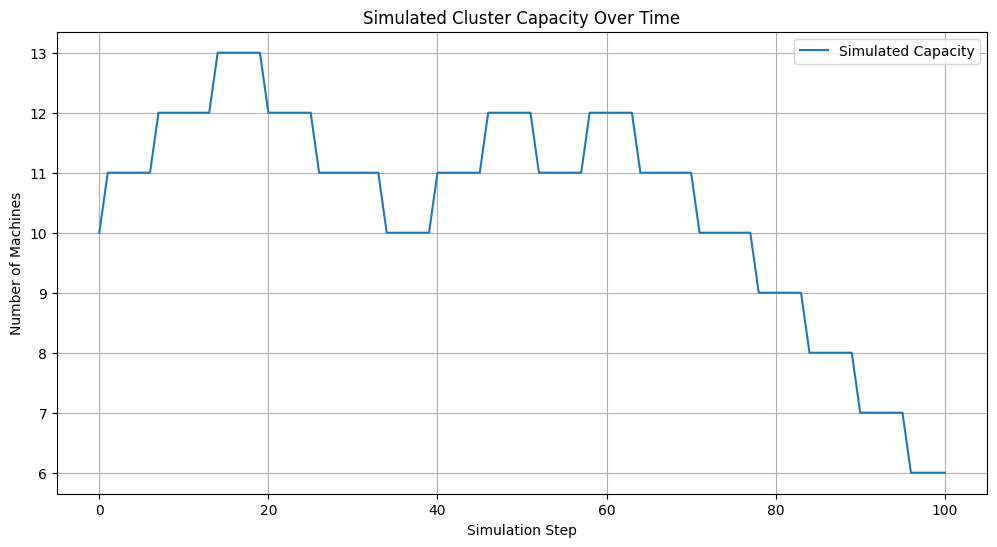

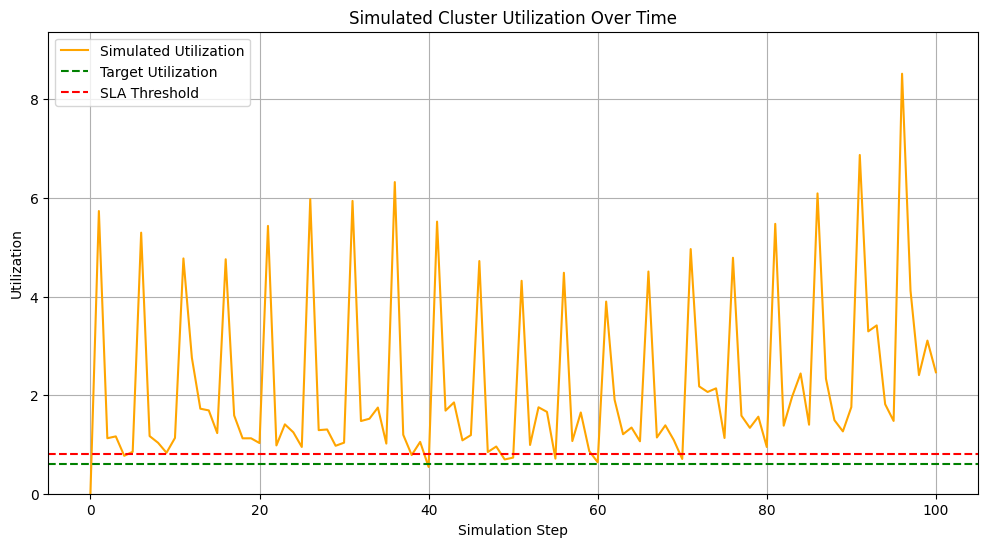

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure the simulation loop in the previous cell has been run
# The lists 'capacities' and 'utilizations' should be available

# Create a time axis based on the number of steps
steps = range(len(capacities))

# Plot Capacity over Time
plt.figure(figsize=(12, 6))
plt.plot(steps, capacities, label='Simulated Capacity')
plt.xlabel('Simulation Step')
plt.ylabel('Number of Machines')
plt.title('Simulated Cluster Capacity Over Time')
plt.grid(True)
plt.legend()
plt.show()

# Plot Utilization over Time
plt.figure(figsize=(12, 6))
plt.plot(steps, utilizations, label='Simulated Utilization', color='orange')
plt.axhline(y=env.config.target_utilization, color='g', linestyle='--', label='Target Utilization')
plt.axhline(y=env.config.sla_threshold, color='r', linestyle='--', label='SLA Threshold')
plt.xlabel('Simulation Step')
plt.ylabel('Utilization')
plt.title('Simulated Cluster Utilization Over Time')
plt.grid(True)
plt.legend()
plt.ylim(0, max(max(utilizations) * 1.1, env.config.sla_threshold * 1.2)) # Adjust y-axis limit
plt.show()